# Cuaderno 4.1 -- Composición de redes

El propósito de este cuaderno es entender qué sucede cuando alimentamos una red neuronal a otra. Funciona a través de un ejemplo similar al 4.1 y varía ambas redes.

Trabaja a través de las celdas a continuación, ejecutando cada celda a su vez. En varios lugares verás las palabras "TAREA". Sigue las instrucciones en estos lugares y haz predicciones sobre lo que va a suceder o escribe código para completar las funciones.

Contáctame en udlbookmail@gmail.com si encuentras algún error o tienes alguna sugerencia.

In [8]:
# Importa la librería de matemáticas
import numpy as np
# Importa la librería de trazado
import matplotlib.pyplot as plt

In [9]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [10]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y

In [11]:
# # Grafica dos redes neuronales poco profundas y la composición de ambas
def plot_neural_two_components(x_in, net1_out, net2_out, net12_out=None):

  # Grafica las dos redes por separado
  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(8.5, 8.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_in, net1_out,'r-')
  ax[0].set_xlabel('Entrada de la Red 1'); ax[0].set_ylabel('Salida de la Red 1')
  ax[0].set_xlim([-1,1]);ax[0].set_ylim([-1,1])
  ax[0].set_aspect(1.0)
  ax[1].plot(x_in, net2_out,'b-')
  ax[1].set_xlabel('Entrada de la Red 2'); ax[1].set_ylabel('Salida de la Red 2')
  ax[1].set_xlim([-1,1]);ax[1].set_ylim([-1,1])
  ax[1].set_aspect(1.0)
  plt.show()

  if net12_out is not None:
    # Grafica su composición
    fig, ax = plt.subplots()
    ax.plot(x_in ,net12_out,'g-')
    ax.set_xlabel('Entrada de la Red 1'); ax.set_ylabel('Salida de la Red 2')
    ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
    ax.set_aspect(1.0)
    plt.show()

Definamos dos redes. Pondremos los prefijos n1_ y n2_ antes de todas las variables para dejar claro qué red es cuál. Solo consideraremos las entradas y salidas en el rango [-1,1]. Si configuras el indicador "plot_all" en True, podrás ver los detalles de cómo fueron creadas.

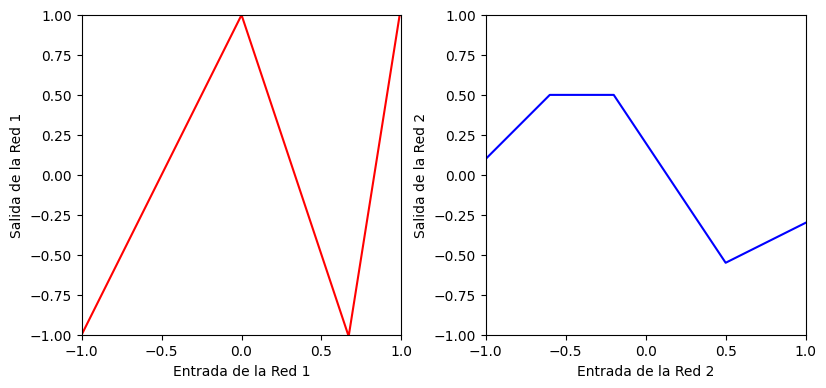

In [12]:
# Ahora definamos algunos parámetros y ejecutemos la primera red neuronal
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Ahora definamos algunos parámetros y ejecutemos la segunda red neuronal
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Muestra las dos entradas
x = np.arange(-1,1,0.001)
# Ejecutamos las primera y segunda redes neuronales para cada uno de estos valores de entrada
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# Grafica ambos gráficos
plot_neural_two_components(x, net1_out, net2_out)

In [13]:
# TAREA
# Toma una hoja de papel y dibuja lo que crees que sucederá cuando alimentemos
# la salida de la primera red a la segunda. Dibuja la relación entre
# la entrada de la primera red y la salida de la segunda.
# --- será la primera curva doblada, luego recortada de acuerdo con la segunda, y al final un perfil similar al primero

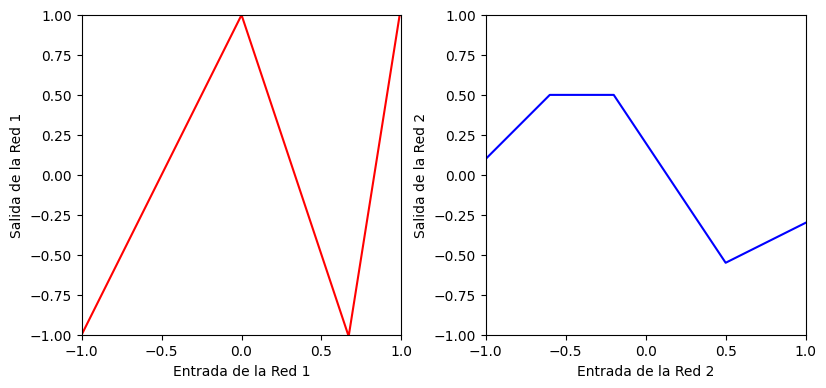

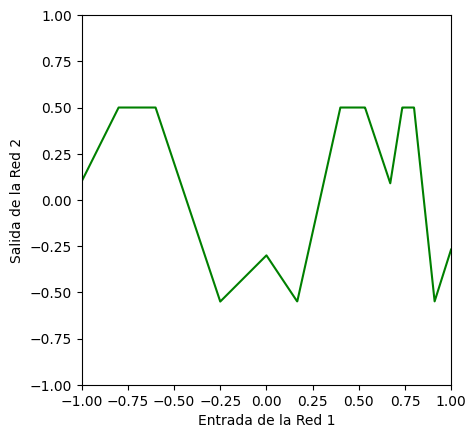

In [14]:
# Ahora veamos si tus predicciones fueron correctas

# TAREA alimenta la salida de la primera red a la segunda red (reemplaza esta línea)
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)

# Grafica los tres gráficos
plot_neural_two_components(x, net1_out, net2_out, net12_out)

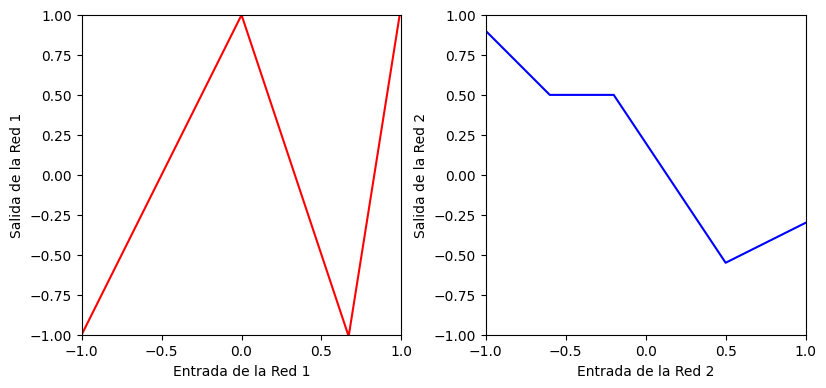

In [15]:
# Ahora vamos a cambiar un poco las cosas. ¿Qué pasa si cambiamos la segunda red? (observa el cambio *-1)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [16]:
# TAREA
# Toma una hoja de papel y dibuja lo que crees que sucederá cuando alimentemos
# la salida de la primera red a la segunda, ahora que la hemos cambiado. Dibuja la relación entre
# la entrada de la primera red y la salida de la segunda.

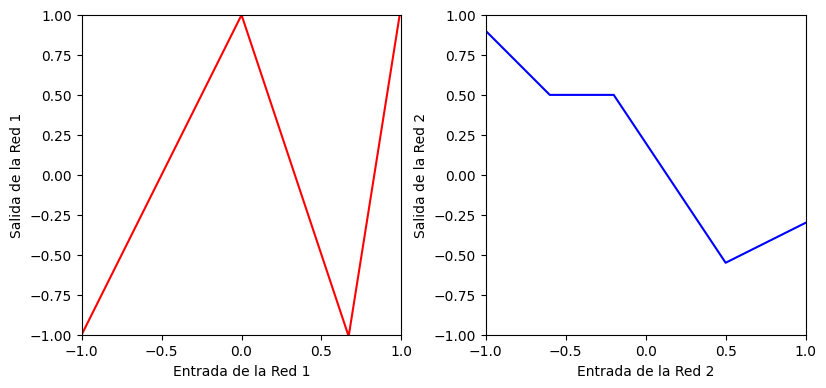

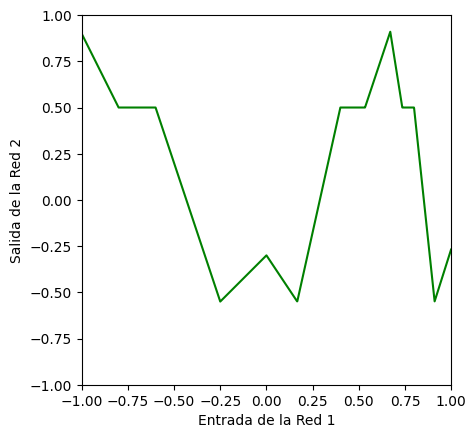

In [17]:
# Cuando tengas una predicción, ejecuta este código para ver si tenías razón
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1*-1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

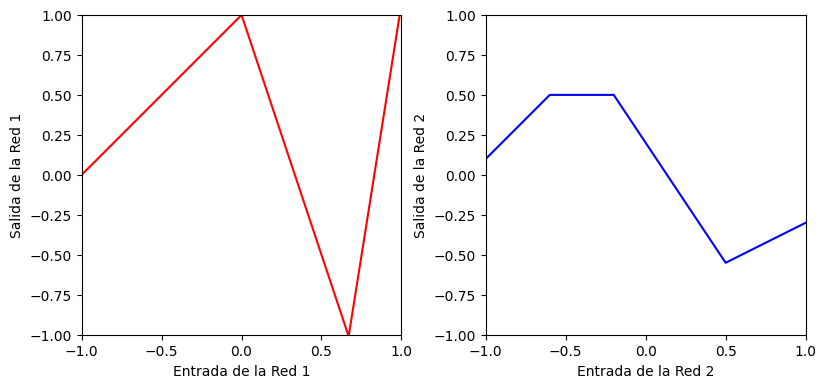

In [18]:
# Cambiemos las cosas de nuevo. ¿Qué pasa si cambiamos la primera red? (observa los cambios)
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1*0.5, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out = shallow_1_1_3(x, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out)

In [19]:
# TAREA
# Toma una hoja de papel y dibuja lo que crees que sucederá cuando alimentemos
# la salida de la primera red, ahora que la hemos cambiado, a la segunda red original. Dibuja la relación entre
# la entrada de la primera red y la salida de la segunda.

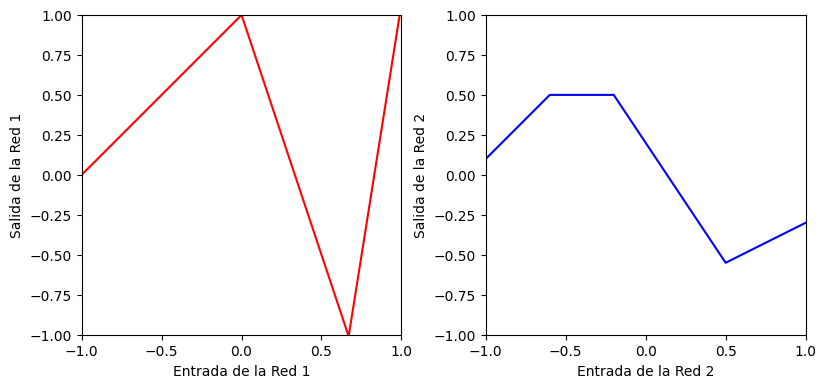

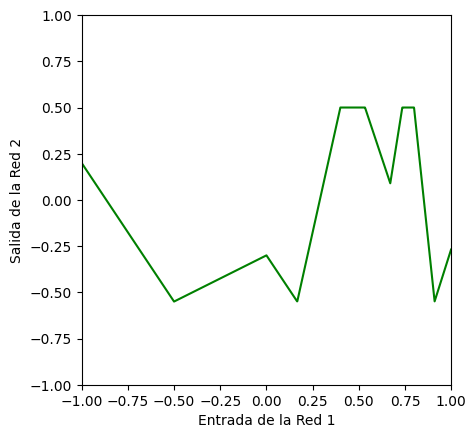

In [20]:
# Cuando tengas una predicción, ejecuta este código para ver si tenías razón
net12_out = shallow_1_1_3(net1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net1_out, net2_out, net12_out)

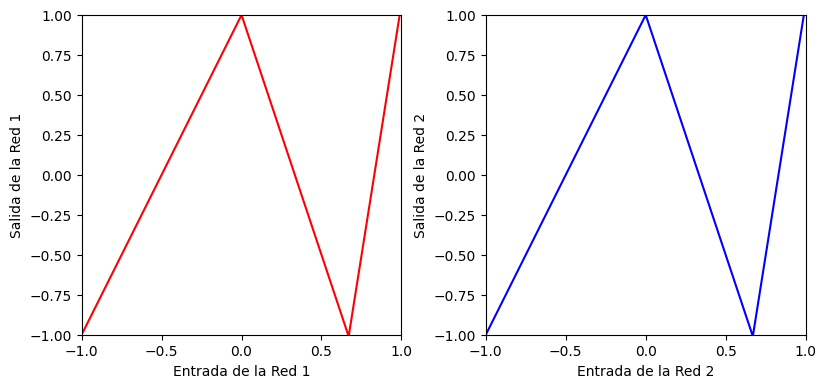

In [21]:
# Cambiemos las cosas de nuevo. ¿Qué pasa si la primera red y la segunda red son iguales?
net1_out = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
net2_out_new = shallow_1_1_3(x, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new)

In [22]:
# TAREA
# Toma una hoja de papel y dibuja lo que crees que sucederá cuando alimentemos
# la salida de la primera red a la segunda red original. Dibuja la relación entre
# la entrada de la primera red y la salida de la segunda.

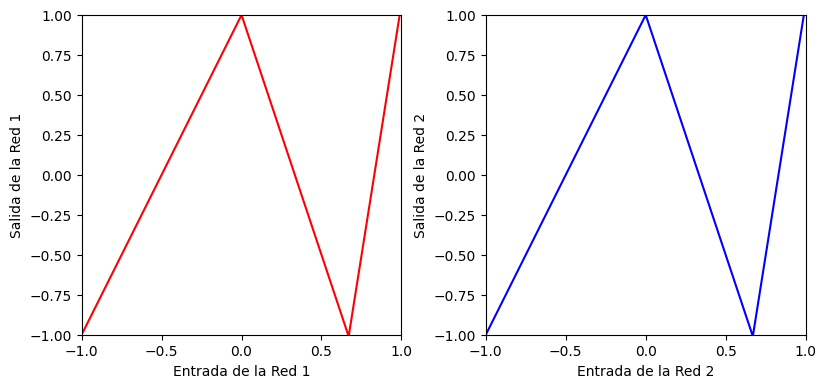

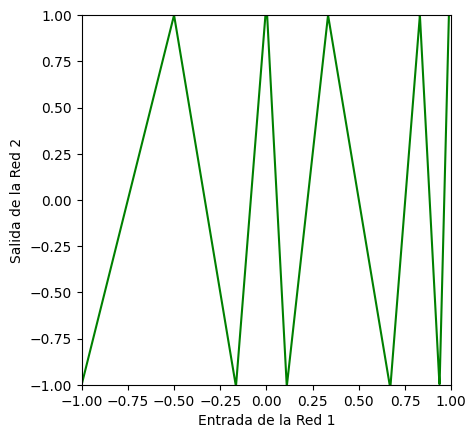

In [23]:
# Cuando tengas una predicción, ejecuta este código para ver si tenías razón
net12_out = shallow_1_1_3(net1_out, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
plot_neural_two_components(x, net1_out, net2_out_new, net12_out)

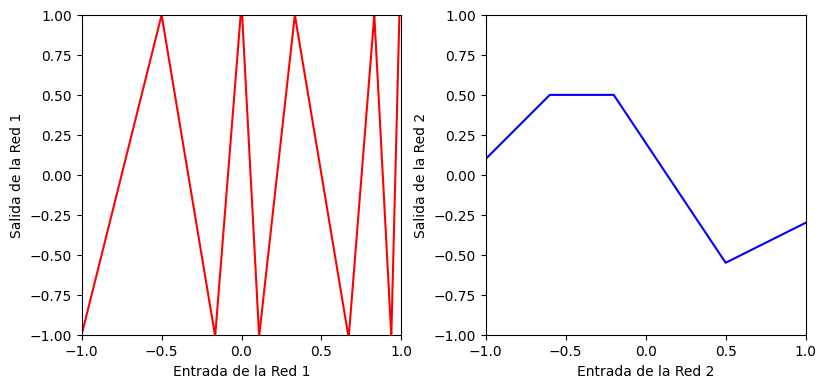

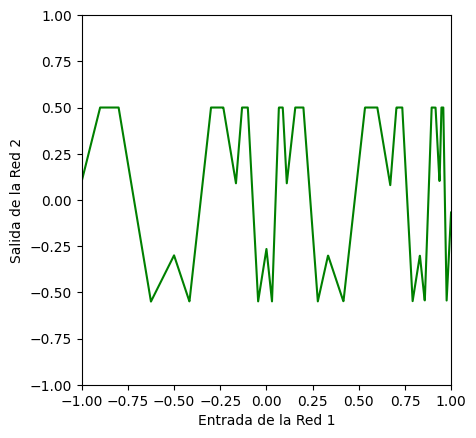

In [24]:
# TAREA
# Contempla lo que crees que sucederá cuando alimentemos
# la salida de la primera red original a una segunda copia de la primera red original, y luego
# la salida de esa a la segunda red original (así ahora tenemos una red de tres capas)
# ¿Cuántas regiones lineales totales tendremos en la salida?
net123_out = shallow_1_1_3(net12_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
plot_neural_two_components(x, net12_out, net2_out, net123_out)

In [25]:
# TAREA
# ¿Cuántas regiones lineales habría si ejecutáramos N copias de la primera red, alimentando el resultado de la primera
# a la segunda, la segunda a la tercera y así sucesivamente, y luego pasáramos el resultado a la segunda
# red original (curva azul de arriba)?

# Conclusión clave: con muy pocos parámetros, podemos crear MUCHAS regiones lineales, pero
# dependen unas de otras de formas complejas que rápidamente se vuelven demasiado difíciles de entender intuitivamente.

¿Cuántas regiones lineales habría si ejecutáramos N copias de la primera red, alimentando el resultado de la primera
a la segunda, la segunda a la tercera y así sucesivamente, y luego pasáramos el resultado a la segunda
red original
(curva azul de arriba)?

**Solucion**: Considerando una red neuronal poco profunda con $K$$K$ unidades ocultas ReLU para una entrada unidimensional, cada red (net1 y net2) exhibe un máximo de $K+1$$K+1$ regiones lineales. Dado que ambas redes (shallow_1_1_3) emplean $K=3$$K=3$ unidades ReLU, cada instancia posee a lo sumo $3+1=4$$3+1=4$ regiones lineales. Cuando $N$$N$ copias de la primera red se componen secuencialmente (es decir, $f_N(x) = f(f(...f(x)...))$$f_N(x) = f(f(...f(x)...))$; $N$$N$ veces), el número máximo de regiones lineales en $f_N(x)$$f_N(x)$ es $(K+1)^N = 4^N$$(K+1)^N = 4^N$. Si esta función compuesta $f_N(x)$$f_N(x)$ se introduce como entrada en la segunda red original, $g(x)$$g(x)$, la función resultante $g(f_N(x))$$g(f_N(x))$ tendrá un número máximo de regiones lineales dado por el producto del número de regiones lineales de $g(x)$$g(x)$ y $f_N(x)$$f_N(x)$. Por lo tanto, la cantidad total de regiones lineales será a lo sumo $(K+1) \times (K+1)^N = 4 \times 4^N = 4^{N+1}$